# Atividade

In [21]:
import numpy as np
import matplotlib.pyplot as plt

## Lagrange

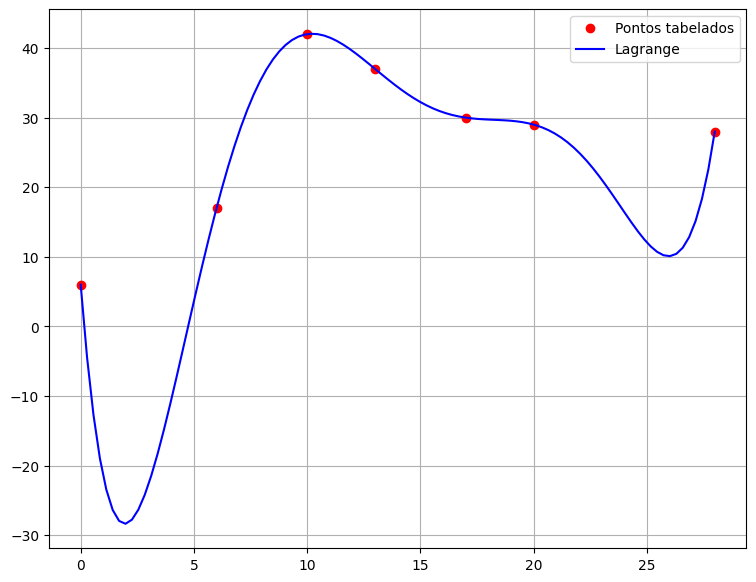

In [22]:
xi = np.array([0., 6, 10, 13, 17, 20, 28])
yi = np.array([6., 17, 42, 37, 30, 29, 28])

n = xi.shape[0]

N = 100

# cria uma malha espalhando os pontos
x = np.linspace(xi[0], xi[n - 1], N)
 
L = np.ones((n, N))

for i in range (0, n):
    for j in range (0, n):
        if i != j:
            L[i, :] *= (x - xi[j]) / (xi[i] - xi[j])

y = yi @ L 

plt.figure(figsize=(9, 7))
plt.plot(xi, yi, 'ro', label='Pontos tabelados')
plt.plot(x, y, 'b-', label='Lagrange')
plt.grid()
plt.legend()
plt.show()

## Newton

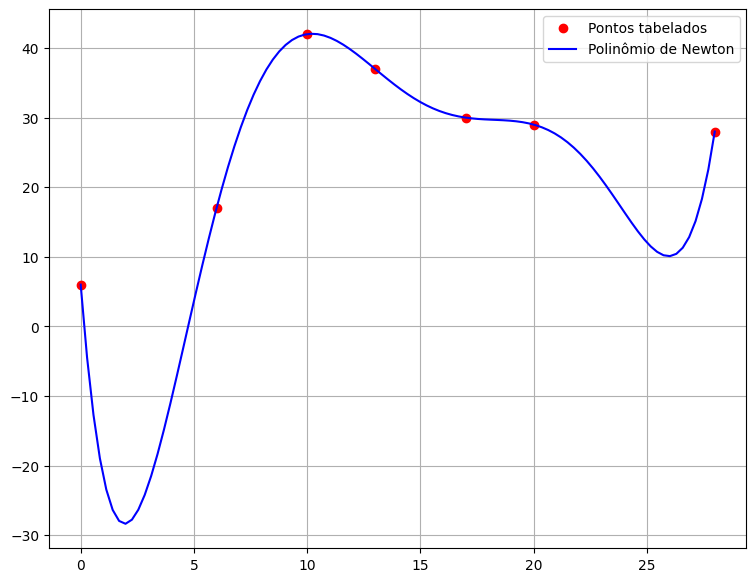

In [23]:
xi = np.array([0., 6, 10, 13, 17, 20, 28])
yi = np.array([6., 17, 42, 37, 30, 29, 28])
n = xi.shape[0]

N = 100

x = np.linspace(xi[0], xi[n - 1], N)

D = np.zeros((n, n))

D[:, 0] = yi.T

# Calcula todas as diferenças Divididas
for j in range(1, n):
    for i in range (j, n):
        D[i,j] = (D[i, j-1] - D[i-1, j-1]) / (xi[i] - xi[i-j])

c = np.diag(D)

y = np.ones(N) * c[0] 

xv = np.ones(N)

for j in range (1, n):
    xv *= (x - xi[j-1])
    y = y + c[j] * xv

plt.figure(figsize=(9, 7))
plt.plot(xi, yi, 'ro', label='Pontos tabelados')
plt.plot(x, y, 'b-', label='Polinômio de Newton')
plt.grid()
plt.legend()
plt.show()



## Splines cúbica

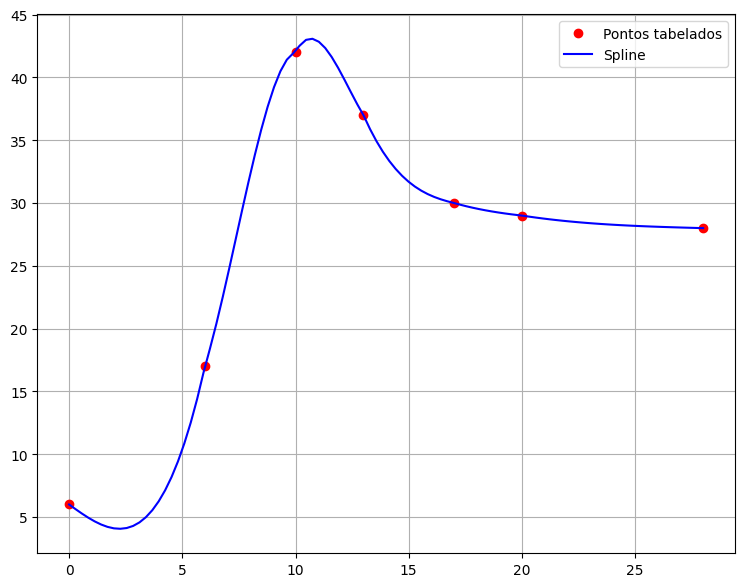

In [24]:
xi = np.array([0., 6, 10, 13, 17, 20, 28])
yi = np.array([6., 17, 42, 37, 30, 29, 28])

n = xi.shape[0]

N = 100

x = np.linspace(xi[0], xi[n - 1], N)

m = n - 1

h = np.zeros(n-1)

for i in range (0, n-1):
    h[i] = xi[i+1] - xi[i]


a = yi
A = np.zeros((n, n))
r = np.zeros(n)

A[0,0] = 1
A[n-1,n-1] = 1

for j in range(1, n-1):
    A[j, j-1] = h[j-1]
    A[j, j] = 2 * h[j-1] + h[j]
    A[j, j+1] = h[j]
    r[j] = 3 * ((a[j+1] - a[j]) / h[j] - (a[j] - a[j-1]) / h[j-1])

c = np.linalg.solve(A, r)

d = np.zeros(m)

b = np.zeros(m)

for j in range (0, m):
    d[j] = (c[j+1] - c[j]) / (3 * h[j])
    b[j] = (a[j+1] - a[j]) / h[j] - h[j] / 3 * (2 * c[j] + c[j+1])


y = np.zeros(N)

for k in range (0, N):
    id = m
    for j in range (0, m):
        if x[k] <= xi[j+1]:
            id = j
            break
    t = x[k] - xi[id]
    y[k] = a[id] + b[id] * t + c[id] * t**2 + d[id] * t ** 3

plt.figure(figsize=(9, 7))
plt.plot(xi, yi, 'ro', label='Pontos tabelados')
plt.plot(x, y, 'b-', label='Spline')
plt.grid()
plt.legend()
plt.show()
